<a href="https://colab.research.google.com/github/Nois12/AIFFEL_quest_rs/blob/main/MainQuest/Quest01/GPTstructure%20_chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Sentencepiece 설치
2. 라이브러리 불러오기
3. 데이터 수집
4. Tokenizer 학습
5. GPT용 Dataset 구현 (단일 시퀀스 결합)
6. Train / Validation / Test Dataset 구성
7. 데이터 로더 구성
8. 모델 정의 및 학습 (GPT-1, 디코더 전용)
9. 디코더 (Masked Self-Attention + FFN)
10. 하이퍼파라미터 / 모델 생성 / 모델 구조 확인
11. 훈련
12. 학습 결과 및 최종 Test 평가
13. 챗봇 테스트

## Transformer(인코더-디코더) → GPT (only 디코더) 변경사항
| 블록                    | 기존 Transformer                                                               | 변경 후 (GPT-1)                                                                                     | 근거                       |
| --------------------- | ---------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------ | ------------------------ |
| **인코더 전체**            | `Encoder`, `EncoderLayer` 존재. Q(질문)를 인코더에 입력                                 | 완전히 삭제                                                                                           | GPT는 디코더 전용 모델이며 인코더가 없다 |
| **인코더-디코더 어텐션**       | `DecoderLayer` 내부에 `encdec_mha` (Cross-Attention) 존재, 인코더 출력을 K, V로 사용       | 완전히 삭제. 디코더 블록은 `Masked Multi-Head Attention → Add&Norm → Feed Forward → Add&Norm`의 2개 서브레이어만 가짐 | Cross-Attention 박스 삭제    |
| **디코더 블록 반복 구조**      | Self-Attention + Cross-Attention + FFN (3개 서브레이어) × N                        | Masked Self-Attention + FFN (2개 서브레이어) × N                                                       |                          |
| **입력(위치 정보)**         | `PositionalEncoding` — 고정된 sin/cos 함수 기반 위치 인코딩을 임베딩에 더함                     | 학습형 Position Embedding — `nn.Embedding`으로 위치마다 학습 가능한 벡터를 두고 토큰 임베딩과 더함                          |                          |
| **모델 입력 (인코더 입력 자체)** | 인코더 입력(Q)과 디코더 입력(A)이 분리되어 있음 (`enc_input`, `dec_input`)                     | Q, A를 하나의 시퀀스로 결합: `<s> Q </s> A </s>` 형태로 만들어 디코더 하나에만 입력                                       |                          |
| **최종 출력층**            | 디코더 출력 → `final_linear`(Linear) → (Loss 계산 시 CrossEntropy가 내부적으로 softmax 적용) | 동일하게 유지: 디코더 출력 → `final_linear`(Linear) → Softmax                                               |                          |
| **마스크**               | 인코더용 패딩 마스크 + 디코더용 (look-ahead + 패딩) 마스크 + 인코더-디코더용 패딩 마스크, 총 3종류            | look-ahead + 패딩 마스크 1종류만 사용 (단일 시퀀스에 대한 causal mask)                                             | 인코더가 없으므로 인코더 관련 마스크 불필요 |


### Sentencepiece 설치

In [ ]:
!pip install sentencepiece

### 라이브러리 불러오기

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import math
import copy
import os
import re
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 데이터 수집

In [ ]:
data_dir = os.path.expanduser("~/work/gpt_chatbot/data")
os.makedirs(data_dir, exist_ok=True)
data_path = os.path.join(data_dir, "ChatbotData.csv")

if not os.path.exists(data_path):
    print(f"Downloading ChatbotData.csv to {data_path} ...")
    url = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
    urllib.request.urlretrieve(url, data_path)
    print("Download complete.")

print("data_path:", data_path)

Download complete.
data_path: /root/work/gpt_chatbot/data/ChatbotData.csv


In [ ]:
df = pd.read_csv(data_path)
print("전체 행 개수 :", len(df))
df.head()

전체 행 개수 : 11823


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [ ]:
MAX_SAMPLES = min(50000, len(df))
print(MAX_SAMPLES)

11823


In [ ]:
def preprocess_sentence(sentence):
  sentence = str(sentence).strip()

  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

  sentence = re.sub(r"\s+", " ", sentence)

  sentence = re.sub(r"[^0-9a-zA-Zㄱ-ㅎㅏ-ㅣ가-힣?.!,]+", " ", sentence)
  sentence = re.sub(r"\s+", " ", sentence).strip()
  return sentence

In [ ]:
def build_pairs(df, max_samples=None):
    questions = df["Q"].astype(str).apply(preprocess_sentence).tolist()
    answers = df["A"].astype(str).apply(preprocess_sentence).tolist()
    pairs = list(zip(questions, answers))
    if max_samples is not None:
        pairs = pairs[:max_samples]
    return pairs

In [ ]:
# 전체 병렬 데이터 생성
pairs = build_pairs(df, max_samples=MAX_SAMPLES)

# Train / Validation / Test 분할
rng = np.random.default_rng(42)
indices = rng.permutation(len(pairs))

train_ratio = 0.80
val_ratio = 0.10

train_end = int(len(indices) * train_ratio)
val_end = train_end + int(len(indices) * val_ratio)

train_pairs = [pairs[i] for i in indices[:train_end]]
val_pairs = [pairs[i] for i in indices[train_end:val_end]]
test_pairs = [pairs[i] for i in indices[val_end:]]

print(f"전체 샘플 수 : {len(pairs)}")
print(f"Train        : {len(train_pairs)} ({len(train_pairs)/len(pairs):.1%})")
print(f"Validation   : {len(val_pairs)} ({len(val_pairs)/len(pairs):.1%})")
print(f"Test         : {len(test_pairs)} ({len(test_pairs)/len(pairs):.1%})")
print("\nTrain 예시:", train_pairs[:2])

전체 샘플 수 : 11823
Train        : 9458 (80.0%)
Validation   : 1182 (10.0%)
Test         : 1183 (10.0%)

Train 예시: [('딱 내 취향인데', '용기를 내보세요 .'), ('돈 좀 빌려줘', '저는 돈이 없어요 .')]


### Tokenizer 학습하기

In [ ]:
# Tokenizer는 Train 데이터만 사용해 학습
# Validation/Test 문장은 모델 평가에만 사용되도록 분리
corpus_file = "clean_corpus_train.txt"
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in train_pairs:
        f.write(q + "\n")
        f.write(a + "\n")

In [ ]:
# ChatbotData.csv에 대해 학습이 잘 되는지 검증
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix="spm_chatbot",
    vocab_size=8000,
    character_coverage=1.0,
    model_type="bpe",
    max_sentence_length=999999,
    bos_id=1,  # <s> (Beginning of Sentence) 설정
    eos_id=2,  # </s> (End of Sentence) 설정
    pad_id=0,  # Padding ID 설정
    unk_id=3   # Unknown Token ID 설정
)

True

In [ ]:
sp = spm.SentencePieceProcessor()
sp.Load("spm_chatbot.model")

True

In [ ]:
sentence = "저는 파이토치로 센텐스피스를 공부하고 있어요!"

sentence = preprocess_sentence(sentence)
print("전처리 후의 문장:", sentence)

# 1. 토크나이징 (subword 단위로 분할)
tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

# 2. 인코딩 (서브워드를 정수 ID로 변환)
encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

# 3. 디코딩 (정수 ID → 원본 문장 복원)
decoded = sp.decode(encoded)
print("Decoded:", decoded)

전처리 후의 문장: 저는 파이토치로 센텐스피스를 공부하고 있어요 !
Tokenized: ['▁저는', '▁파', '이', '토', '치', '로', '▁센', '텐', '스피', '스', '를', '▁공부', '하고', '▁있어요', '▁!']
Encoded: [596, 795, 6801, 7412, 6967, 6839, 2468, 7175, 3024, 6890, 6858, 334, 69, 114, 110]
Decoded: 저는 파이토치로 센텐스피스를 공부하고 있어요 !


### GPT 구조의 Dataset 구현하기

[수정] 기존에는 인코더 입력(질문)과 디코더 입력(답변)을 분리했지만, GPT 구조는 인코더가 없으므로 하나의 시퀀스로 합쳐서 넣는다.

시퀀스 구성: `<s> Q_tokens </s> A_tokens </s>`


이렇게 만든 하나의 시퀀스에 대해 다음 토큰 예측 방식으로 causal LM 학습을 수행한다 (`input_ids = seq[:-1]`, `target_ids = seq[1:]`).

In [ ]:
class ChatbotDataset(Dataset):
    # [수정] 인코더/디코더 입력을 분리하던 기존 ChatbotDataset을 대체.
    # 질문(Q)과 답변(A)을 하나의 시퀀스로 이어붙여 단일 디코더에 입력한다.
    def __init__(self, pairs, sp, max_length=80):
        super().__init__()
        self.sp = sp
        self.max_length = max_length
        self.data = []

        bos_id = sp.bos_id() if sp.bos_id() >= 0 else 1
        eos_id = sp.eos_id() if sp.eos_id() >= 0 else 2

        for q_text, a_text in pairs:
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            # [수정] <s> Q </s> A </s> 형태로 하나의 시퀀스 구성
            # 첫 </s>: Q/A 구분용 delimiter, 마지막 </s>: 시퀀스 종료 토큰
            seq = [bos_id] + q_ids + [eos_id] + a_ids + [eos_id]

            if len(seq) > max_length:
                continue

            # 고정 길이 패딩
            seq = seq + [0] * (max_length - len(seq))

            # [수정] 인코더 입력이 없으므로 input_ids / target_ids 두 개만 반환 (다음 토큰 예측을 위해 한 칸씩 밀어서 사용)
            input_ids = seq[:-1]
            target_ids = seq[1:]

            self.data.append({"input_ids": input_ids, "target_ids": target_ids})

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        input_ids = torch.tensor(sample["input_ids"], dtype=torch.long)
        target_ids = torch.tensor(sample["target_ids"], dtype=torch.long)
        return input_ids, target_ids

### Train / Validation / Test Dataset 구성

In [ ]:
MAX_LENGTH = 80

train_dataset = ChatbotDataset(train_pairs, sp, max_length=MAX_LENGTH)
val_dataset = ChatbotDataset(val_pairs, sp, max_length=MAX_LENGTH)
test_dataset = ChatbotDataset(test_pairs, sp, max_length=MAX_LENGTH)

print(f"원본 분할 수      - Train: {len(train_pairs)}, Val: {len(val_pairs)}, Test: {len(test_pairs)}")
print(f"길이 필터 후      - Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

원본 분할 수      - Train: 9458, Val: 1182, Test: 1183
길이 필터 후      - Train: 9458, Val: 1182, Test: 1183


### Train Dataset의 샘플 구조 확인

In [ ]:
# [수정] 인코더 입력이 없으므로 input_ids / target_ids 두 개만 확인
input_ids, target_ids = train_dataset[0]
print("Input 크기:", input_ids.size())
print(input_ids)
print("Input 문장 :", sp.decode(input_ids.tolist()))
print("Target 크기:", target_ids.size())
print(target_ids)
print("Target 문장:", sp.decode(target_ids.tolist()))

Input 크기: torch.Size([79])
tensor([   1,  875,   53, 2355,  203,    2, 1717, 2650,    4,    2,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0])
Input 문장 : 딱 내 취향인데 용기를 내보세요 .
Target 크기: torch.Size([79])
tensor([ 875,   53, 2355,  203,    2, 1717, 2650,    4,    2,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,  

### 데이터로더 구성하기

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 296
Validation batches: 37
Test batches: 37


In [ ]:
for input_ids, target_ids in train_loader:
    print("Train batch input :", input_ids.size())
    print("Train batch target:", target_ids.size())
    break

Train batch input : torch.Size([32, 79])
Train batch target: torch.Size([32, 79])


### 모델 정의 및 학습하기

In [ ]:
# [수정] look-ahead 마스크(미래 토큰 차단) + 패딩 마스크만 사용한다.

def create_padding_mask(x):
    # x: (batch_size, seq_len)
    mask = (x == 0)
    return mask.unsqueeze(1).unsqueeze(2)  # (batch_size, 1, 1, seq_len)

def create_look_ahead_mask(x):
    # 디코더 셀프 어텐션용: 미래 시점을 보지 못하게 하는 마스크 + 패딩 마스크를 합친다.
    seq_len = x.size(1)
    look_ahead_mask = torch.triu(
        torch.ones((seq_len, seq_len), device=x.device), diagonal=1
    ).bool()
    look_ahead_mask = look_ahead_mask.unsqueeze(0).unsqueeze(0)  # (1, 1, seq_len, seq_len)
    padding_mask = create_padding_mask(x)  # (batch_size, 1, 1, seq_len)
    return look_ahead_mask | padding_mask

### 입력 블럭 수정: 학습형 Position Embedding

[수정] 기존 `PositionalEncoding`은 sin/cos 함수로 계산되는 고정된 위치 인코딩이었다.
따라서 `nn.Embedding`으로 위치마다 학습되는 벡터(`pos_emb`)를 두고, 토큰 임베딩에 더하는 방식으로 교체한다.

In [ ]:
class PositionEmbedding(nn.Module):
    # [수정] 고정 sin/cos PositionalEncoding 대신 학습형 위치 임베딩(Wp) 사용
    def __init__(self, max_position, d_model):
        super(PositionEmbedding, self).__init__()
        self.position_embedding = nn.Embedding(max_position, d_model)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model) - 토큰 임베딩이 이미 적용된 상태
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)  # (1, seq_len)
        return x + self.position_embedding(positions)

### 멀티 헤드 어텐션

 인코더-디코더 어텐션에서 쓰이던 K, V를 인코더 출력이 아닌 자기 자신의 시퀀스에서만 가져오도록 호출 방식만 바뀐다.

In [ ]:
# 멀티 헤드 어텐션
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)
        self.dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)

    def scaled_dot_product_attention(self, query, key, value, mask=None):
        matmul_qk = torch.matmul(query, key.transpose(-2, -1))
        depth = key.size(-1)
        logits = matmul_qk / math.sqrt(depth)
        if mask is not None:
            logits = logits.masked_fill(mask, -1e9)
        attention_weights = F.softmax(logits, dim=-1)
        output = torch.matmul(attention_weights, value)
        return output, attention_weights

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        query = self.split_heads(self.query_dense(query), batch_size)
        key = self.split_heads(self.key_dense(key), batch_size)
        value = self.split_heads(self.value_dense(value), batch_size)

        scaled_attention, _ = self.scaled_dot_product_attention(query, key, value, mask)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        outputs = self.dense(concat_attention)
        return outputs

## 디코더

[수정] `Masked Self-Attention → FFN`의 2개 서브레이어만 남긴다.

In [ ]:
class DecoderLayer(nn.Module):
    # [수정] 기존 DecoderLayer에서 인코더-디코더 어텐션(encdec_mha) 서브레이어를 완전히 삭제.
    # Masked Self-Attention + FeedForward 2개 서브레이어만 남김.
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()
        # 첫 번째 서브 레이어: Masked Multi-Head Self-Attention
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # [수정] 두 번째 서브 레이어(인코더-디코더 어텐션)는 삭제

        # 두 번째 서브 레이어: Feed Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, look_ahead_mask=None):
        # 1) Masked Self-Attention
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # Add & Norm

        # [수정] 인코더-디코더 어텐션 블록 삭제

        # 2) Feed Forward
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout2(ffn_out)
        out2 = self.norm2(out1 + ffn_out)  # Add & Norm
        return out2

In [ ]:
class Decoder(nn.Module):
    # [수정] 기존 Decoder를 대체. enc_outputs, padding_mask(인코더용) 인자를 제거하고
    # 위치 인코딩을 학습형 PositionEmbedding으로 교체.
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 max_position,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model
        # (1) 토큰 임베딩 레이어 (We)
        self.embedding = nn.Embedding(vocab_size, d_model)
        # (2) [수정] 학습형 위치 임베딩 (Wp)
        self.pos_embedding = PositionEmbedding(max_position, d_model)
        self.dropout = nn.Dropout(dropout)
        # (3) DecoderLayer 쌓기 (Cross-Attention 없음)
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, look_ahead_mask=None):
        # (1) 토큰 임베딩 + sqrt(d_model) 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)
        # (2) [수정] 학습형 위치 임베딩 더하기
        x = self.pos_embedding(x)
        x = self.dropout(x)
        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, look_ahead_mask)
        return x

In [ ]:
class Model(nn.Module):
    # [수정] 기존 Transformer(인코더+디코더) 클래스를 대체.
    # 인코더를 완전히 제거하고 디코더 스택 하나로만 구성 (Decoder-only).
    def __init__(self,
                 vocab_size,
                 num_layers,      # 디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 max_position,    # 위치 임베딩 최대 길이
                 dropout=0.1):
        super(Model, self).__init__()

        # [수정] self.encoder 삭제

        # 디코더 (Masked Self-Attention + FFN 스택)
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            max_position=max_position,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)  (이미지의 Linear -> Softmax 블록)
        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, inputs):
        # [수정] 인코더 입력이 없으므로 하나의 시퀀스만 받는다.
        # 1) look-ahead + 패딩 마스크 (인코더용 마스크는 없음)
        look_ahead_mask = create_look_ahead_mask(inputs)

        # 2) 디코더 수행 (enc_outputs 인자 없음)
        dec_outputs = self.decoder(
            x=inputs,
            look_ahead_mask=look_ahead_mask
        )  # shape: (batch_size, seq_len, d_model)

        # 3) 최종 Dense (vocab_size) -> 이후 CrossEntropyLoss에서 softmax 적용
        logits = self.final_linear(dec_outputs)  # (batch_size, seq_len, vocab_size)
        return logits

### 하이퍼파라미터 / 모델 생성 / 모델 구조 확인

In [ ]:
# [수정] 인코더/디코더 공용이던 하이퍼파라미터를 디코더 전용으로 정리
NUM_LAYERS = 2     # 디코더 층 수
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 512        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.3      # 드롭아웃 비율
VOCAB_SIZE = 8000  # 단어 집합 크기

# [수정] 위치 임베딩 테이블 크기 = 데이터셋 시퀀스 길이(MAX_LENGTH)
model = Model(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    max_position=MAX_LENGTH,
    dropout=DROPOUT
)

print(model)

Model(
  (decoder): Decoder(
    (embedding): Embedding(8000, 256)
    (pos_embedding): PositionEmbedding(
      (position_embedding): Embedding(80, 256)
    )
    (dropout): Dropout(p=0.3, inplace=False)
    (dec_layers): ModuleList(
      (0-1): 2 x DecoderLayer(
        (self_mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=256, bias=True)
        )
        (norm2): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=

In [ ]:
# model.summary() : 파라미터 수와 각 레이어 shape 확인
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

try:
    from torchinfo import summary
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torchinfo"])
    from torchinfo import summary

dummy_input = torch.randint(1, VOCAB_SIZE, (1, MAX_LENGTH - 1))
summary(model, input_data=dummy_input)

Total parameters     : 5,178,688
Trainable parameters : 5,178,688


Layer (type:depth-idx)                        Output Shape              Param #
Model                                         [1, 79, 8000]             --
├─Decoder: 1-1                                [1, 79, 256]              --
│    └─Embedding: 2-1                         [1, 79, 256]              2,048,000
│    └─PositionEmbedding: 2-2                 [1, 79, 256]              --
│    │    └─Embedding: 3-1                    [1, 79, 256]              20,480
│    └─Dropout: 2-3                           [1, 79, 256]              --
│    └─ModuleList: 2-4                        --                        --
│    │    └─DecoderLayer: 3-2                 [1, 79, 256]              527,104
│    │    └─DecoderLayer: 3-3                 [1, 79, 256]              527,104
├─Linear: 1-2                                 [1, 79, 8000]             2,056,000
Total params: 5,178,688
Trainable params: 5,178,688
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 5.18
Input size (MB): 0.00
Forw

In [ ]:
# 모델 입력이 정상적으로 구성되는지 확인
model.eval()
with torch.no_grad():
    sample_input_ids, _ = train_dataset[0]
    sample_input_ids = sample_input_ids.unsqueeze(0)
    sample_logits = model(sample_input_ids)

print("입력 shape :", sample_input_ids.shape)
print("출력 shape :", sample_logits.shape, "(batch_size, seq_len, vocab_size)")

입력 shape : torch.Size([1, 79])
출력 shape : torch.Size([1, 79, 8000]) (batch_size, seq_len, vocab_size)


In [ ]:
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id(), label_smoothing=0.1)

In [ ]:
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

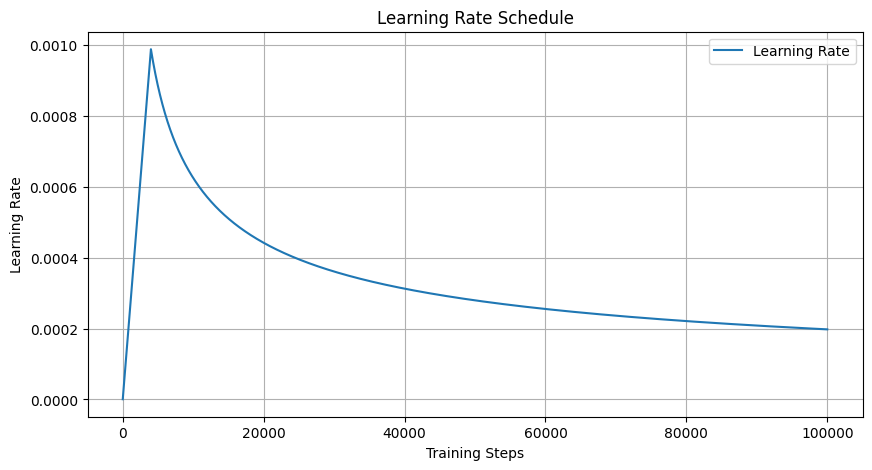

In [ ]:
warmup_steps = 4000
total_steps = 100000  # 총 학습 스텝 (그래프 표시용 가상의 스텝 수)

steps = np.arange(1, total_steps + 1)
learning_rates = [get_lr_lambda(D_MODEL, warmup_steps)(step) for step in steps]

plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Optimizer 정의
optimizer = optim.Adam(
    model.parameters(),
    lr=1.0,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=1e-4
)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=800))

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

### 훈련하기

In [ ]:
def train_step(model, batch, optimizer, loss_function, device):
    # [수정] enc_input 제외 input_ids만 사용
    model.train()
    input_ids, target_ids = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # 모델 포워드 패스
    logits = model(input_ids)  # (batch_size, seq_len, vocab_size)

    # Loss 계산 (패딩 토큰 무시)
    loss = loss_function(logits.permute(0, 2, 1), target_ids)  # (batch_size, vocab_size, seq_len) 필요

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, target_ids, pad_id=sp.pad_id())

In [ ]:
def evaluate(model, dataloader, loss_function, device):
    """Validation/Test용 평가 함수. gradient를 계산하지 않음."""
    # [수정] enc_input 제외 input_ids만 사용
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids, target_ids = [x.to(device) for x in batch]
            logits = model(input_ids)

            loss = loss_function(logits.permute(0, 2, 1), target_ids)
            total_loss += loss.item()

            preds = logits.argmax(dim=-1)
            mask = target_ids != sp.pad_id()
            total_correct += ((preds == target_ids) & mask).sum().item()
            total_tokens += mask.sum().item()

    avg_loss = total_loss / len(dataloader)
    avg_acc = total_correct / total_tokens if total_tokens > 0 else 0.0
    return avg_loss, avg_acc


def train(model, train_loader, val_loader, optimizer, loss_function, scheduler, num_epochs, device, patience=10):
    # [수정] enc_input 없이 input_ids만 사용.
    model.to(device)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_tokens = 0

        for step, batch in enumerate(train_loader):
            loss, _ = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss

            input_ids, target_ids = [x.to(device) for x in batch]
            with torch.no_grad():
                model.eval()
                logits = model(input_ids)
                preds = logits.argmax(dim=-1)
                mask = target_ids != sp.pad_id()
                total_correct += ((preds == target_ids) & mask).sum().item()
                total_tokens += mask.sum().item()
                model.train()

            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}")

            scheduler.step()

        train_loss = total_loss / len(train_loader)
        train_acc = total_correct / total_tokens if total_tokens > 0 else 0.0
        val_loss, val_acc = evaluate(model, val_loader, loss_function, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(best_model_state, "best_chatbot.pt")
            best_mark = " ← best"
            patience_counter = 0
        else:
            best_mark = ""
            patience_counter += 1

        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}{best_mark}"
        )

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1} (patience={patience})")
            break

    # Validation Loss가 가장 낮았던 모델을 복원
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nBest Validation Loss: {best_val_loss:.4f}")
        print("Best model restored.")

    return history

In [ ]:
%%time

NUM_EPOCHS = 30

history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    device=device,
    patience=10
)

[Epoch 1, Step 0] Loss: 9.1804
[Epoch 1, Step 100] Loss: 7.2148
[Epoch 1, Step 200] Loss: 6.8797
Epoch 01 | Train Loss: 7.2091 | Train Acc: 0.1943 | Val Loss: 6.5602 | Val Acc: 0.2261 ← best
[Epoch 2, Step 0] Loss: 6.5508
[Epoch 2, Step 100] Loss: 6.3594
[Epoch 2, Step 200] Loss: 6.4939
Epoch 02 | Train Loss: 6.3527 | Train Acc: 0.2520 | Val Loss: 6.1468 | Val Acc: 0.2480 ← best
[Epoch 3, Step 0] Loss: 5.8539
[Epoch 3, Step 100] Loss: 6.0437
[Epoch 3, Step 200] Loss: 5.9221
Epoch 03 | Train Loss: 5.9724 | Train Acc: 0.2750 | Val Loss: 5.9154 | Val Acc: 0.2614 ← best
[Epoch 4, Step 0] Loss: 5.2971
[Epoch 4, Step 100] Loss: 5.5641
[Epoch 4, Step 200] Loss: 5.8652
Epoch 04 | Train Loss: 5.6276 | Train Acc: 0.2961 | Val Loss: 5.7578 | Val Acc: 0.2713 ← best
[Epoch 5, Step 0] Loss: 5.1469
[Epoch 5, Step 100] Loss: 5.2435
[Epoch 5, Step 200] Loss: 5.4617
Epoch 05 | Train Loss: 5.3424 | Train Acc: 0.3168 | Val Loss: 5.6490 | Val Acc: 0.2823 ← best
[Epoch 6, Step 0] Loss: 4.8974
[Epoch 6, Step

## 학습 결과 및 최종 Test 평가

-> Train/Validation Loss를 Epoch별로 비교하고, Validation Loss가 가장 낮았던 모델을 복원한 뒤 Test 데이터에서 최종 성능을 평가함

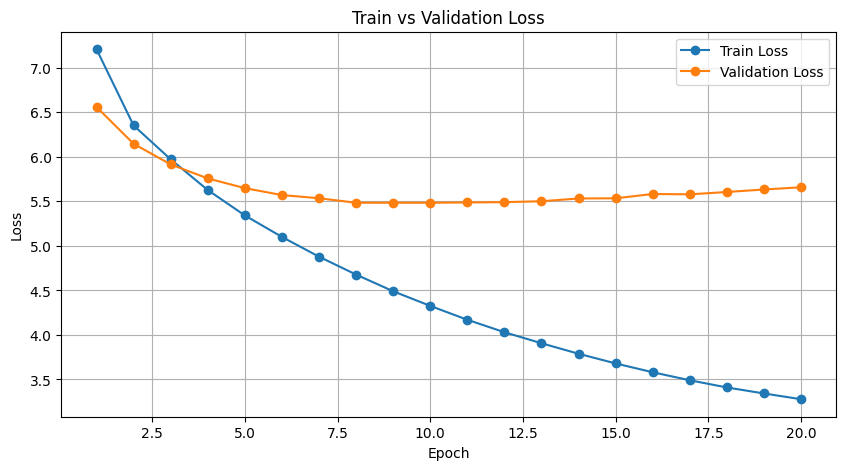

In [ ]:
# Train / Validation Loss 비교
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

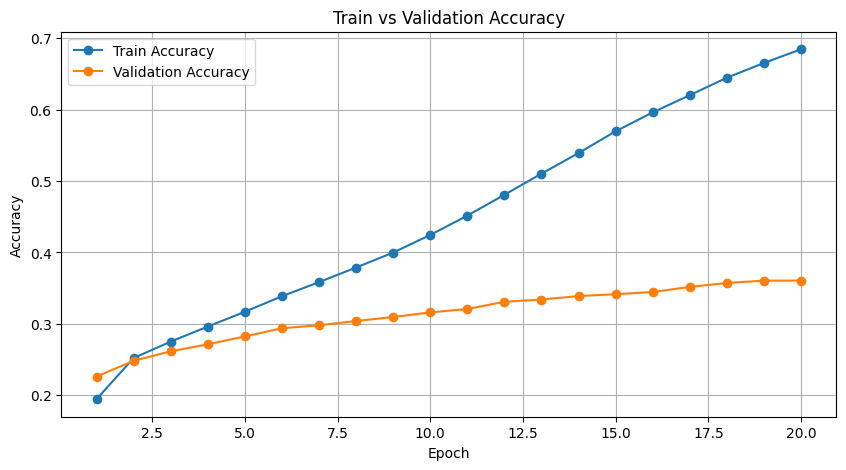

In [ ]:
# Train / Validation Accuracy 비교
plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_acc"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("최종 Train Loss:", history["train_loss"][-1])
print("최종 Train Acc :", history["train_acc"][-1])

print("최종 Val Loss  :", history["val_loss"][-1])
print("최종 Val Acc   :", history["val_acc"][-1])

최종 Train Loss: 3.277819196920137
최종 Train Acc : 0.6846980243833742
최종 Val Loss  : 5.658246104781692
최종 Val Acc   : 0.36055460542389445


In [ ]:
best_epoch = np.argmin(history["val_loss"])

print(f"Best Epoch: {best_epoch + 1}")
print(f"Best Val Loss: {history['val_loss'][best_epoch]:.4f}")
print(f"Best Val Acc : {history['val_acc'][best_epoch]:.4f}")

Best Epoch: 10
Best Val Loss: 5.4844
Best Val Acc : 0.3160


In [ ]:
# 최종 Test 평가: 학습이 끝난 뒤 한 번만 평가
test_loss, test_acc = evaluate(model, test_loader, loss_function, device)

print("=" * 60)
print("최종 Test 결과")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print("=" * 60)

최종 Test 결과
Test Loss     : 5.4786
Test Accuracy : 0.3152


챗봇 테스트

In [ ]:
def decoder_inference(model, sentence, tokenizer, device='cpu', temperature=0.6, top_k=10, max_length=None):
    # [수정] 인코더 입력이 없으므로, "<s> Q </s>"를 prompt로 만들어 디코더 하나에 그대로 넣고 그 뒤를 이어서 생성한다.
    if max_length is None:
        max_length = MAX_LENGTH

    START_TOKEN = tokenizer.bos_id()
    DELIM_TOKEN = tokenizer.eos_id()  # Q/A 구분자 겸 종료 토큰

    sentence = preprocess_sentence(sentence)
    q_ids = tokenizer.encode(sentence)

    # [수정] prompt = <s> Q </s>  (인코더가 없으므로 디코더 입력에 질문까지 포함)
    prompt_ids = [START_TOKEN] + q_ids + [DELIM_TOKEN]
    prompt_ids = prompt_ids[:max_length]

    dec_input = torch.tensor([prompt_ids], dtype=torch.long, device=device)
    prompt_len = dec_input.size(1)

    model.eval()
    with torch.no_grad():
        for _ in range(max_length - prompt_len):
            logits = model(dec_input)
            last_step_logits = logits[:, -1, :] / temperature   # temperature 적용

            # top-k 필터링: 상위 k개만 남기고 나머지는 -inf로
            top_k_logits, top_k_indices = torch.topk(last_step_logits, top_k, dim=-1)
            probs = F.softmax(top_k_logits, dim=-1)
            sampled_idx = torch.multinomial(probs, num_samples=1)  # 확률적으로 샘플링
            predicted_id = top_k_indices.gather(-1, sampled_idx).squeeze(-1)

            if predicted_id.item() == DELIM_TOKEN:
                break

            dec_input = torch.cat([dec_input, predicted_id.unsqueeze(0)], dim=1)

    # [수정] prompt(질문) 이후에 새로 생성된 부분만 답변으로 추출
    generated = dec_input.squeeze(0).tolist()[prompt_len:]
    return generated

In [ ]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # [수정] decoder_inference -> decoder_inference 호출로 변경
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)

    special_ids = {tokenizer.pad_id(), tokenizer.bos_id(), tokenizer.eos_id()}
    output_seq = [token for token in output_seq if token not in special_ids]
    predicted_sentence = tokenizer.decode(output_seq).strip()

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)
    return predicted_sentence

In [ ]:
# 다양한 한국어 문장에 대한 챗봇 응답 테스트
test_sentences = [
    "오늘도 화이팅 해보자",
    "나의 건강이 안좋은 것 같아",
    "오늘 너무 힘들었어",
    "오늘 기분이 정말 좋아",
    "친구랑 싸웠어",
    "시험 때문에 걱정돼",
    "요즘 잠을 잘 못 자",
    "여행 가고 싶어"
]

for sentence in test_sentences:
    sentence_generation(model, sentence, sp, device)
    print("-" * 50)

입력 : 오늘도 화이팅 해보자
출력 : 또 다시 올 거예요 .
--------------------------------------------------
입력 : 나의 건강이 안좋은 것 같아
출력 : 더 힘들죠 .
--------------------------------------------------
입력 : 오늘 너무 힘들었어
출력 : 오늘은 쉬세요 .
--------------------------------------------------
입력 : 오늘 기분이 정말 좋아
출력 : 오늘은 쉬세요 .
--------------------------------------------------
입력 : 친구랑 싸웠어
출력 : 그럴 때가 있죠 .
--------------------------------------------------
입력 : 시험 때문에 걱정돼
출력 : 더 힘들죠 .
--------------------------------------------------
입력 : 요즘 잠을 잘 못 자
출력 : 잠이 안 와 돼요 .
--------------------------------------------------
입력 : 여행 가고 싶어
출력 : 같이 먹든 맛있게 드세요 .
--------------------------------------------------


## model.summary
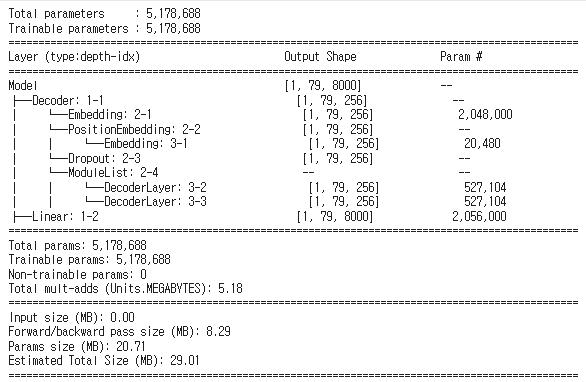

## model.fit
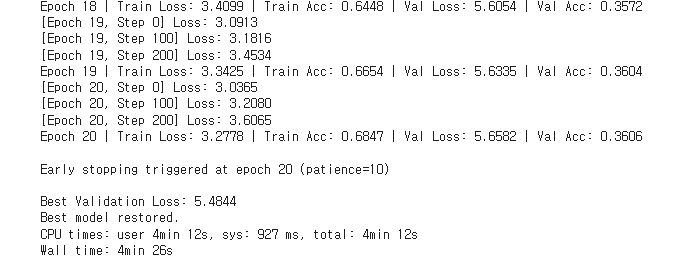

## 결론 분석

### 1. only 디코더 구조로 인한 변화의 영향
- 인코더 제거로 질문이 압축 표현 없이 prompt로 디코더에 그대로 들어감 → 질문-답변 정렬이 느슨해짐
- 파라미터 감소로 수렴은 빠르지만(Val Loss는 Epoch 10 근처 최저), 문맥 일치도는 다소 떨어짐

### 2. 학습 결과
| 항목 | 값 |
|---|---|
| Best Epoch | 10 |
| Best Val Loss / Acc | 5.4844 / 0.3160 |
| Test Loss / Acc | 5.4786 / 0.3152 |
| 최종 Train Loss / Acc | 3.2778 / 0.6847 |

→ Best Epoch 이후 Val Loss는 정체 되거나 소폭 상승, Train만 계속 개선됨 (과적합 패턴)

### 3. 한계
- "힘들었어"/"기분 좋아" → 둘 다 "오늘은 쉬세요." (반대 감정 구분 실패)
- "여행 가고 싶어" → "같이 먹든 맛있게 드세요." (주제 무관, 문법 어색)
- 짧고 정형화된 위로 표현 반복 → 다양성 부족


### 회고

최근에 만들었던 Transformer 모델을 GPT 구조로 변경하면서 인코더를 제거하고, 인코더와 디코더를 연결하던 Encoder-Decoder Attention과 인코더의 입력 및 출력과 관련된 부분도 함께 제거해야 한다는 것을 알게 되었다. 이를 통해 GPT는 Transformer의 Decoder를 기반으로 하는 only decoder 구조라는 것을 확인하고 이해할 수 있게 되었다.